# 02 - Final Modeling

Notebook final pour l'entrainement du modele Random Forest et la sauvegarde des artefacts utilises par l'application.

In [10]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
 )
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import export_text, plot_tree

In [11]:
candidate_paths = [Path("../data/bp_summary_classified.csv"), Path("data/bp_summary_classified.csv"), Path("bp_summary_classified.csv")]
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("bp_summary_classified.csv not found in expected locations")

df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()

Shape: (1580, 47)


,source_file,test_begin,age,sex,date_of_birth,all_avg_sys,all_avg_dia,day_avg_sys,day_avg_dia,day_bp_threshold_sys,...,bp_cv_all_dia_pct,bp_cv_day_sys_pct,bp_cv_day_dia_pct,bp_cv_night_sys_pct,bp_cv_night_dia_pct,contents,diagnostics,aasi_sys,readings_count,health_label
0,ID_0001_cleaned.pdf,2024/03/26 14:01:00,73.0,Male,1951/01/18,132.1,63.9,139.4,71.1,135.0,...,21.2,8.5,15.1,6.6,21.1,CHIFFRES > NLE ET DES PICS A 170/90 MMHG . TRA...,PROFIL TENSIONNEL ELEVE SURTOUT EN PERIODE DIU...,0.17,34,not
1,ID_0002_cleaned.pdf,2021/06/14 10:31:00,68.0,Female,1953/11/19,111.6,58.3,115.3,60.7,135.0,...,15.8,10.8,15.9,5.3,10.0,111/58 MMHG . DR BEN MILED MEHDI,PROFIL TENSIONNEL PARFAITMENT NORMAL AUSSI BIE...,0.56,42,healthy
2,ID_0003_cleaned.pdf,2023/03/04 09:30:00,50.0,Male,1973/03/14,126.1,75.8,131.6,82.6,135.0,...,17.3,7.0,9.1,11.3,13.5,NORMAL. A SURVEILLER SOUS MEUSURES DIETETIQUES...,PROFIL TENSIONNEL LIMITE EN PERIODE DIURNE A V...,0.20,24,not
3,ID_0004_cleaned.pdf,2023/03/08 09:01:00,60.0,Male,1963/08/10,132.3,71.5,138.8,75.0,135.0,...,15.5,10.2,13.3,14.5,14.9,NLE ET DES PICS A 170/89 MMHG. PROFIL NOCTURNE...,PROFIL TENSIONNEL ELEVE EN PERIODE DIURNE A VE...,0.48,42,not
4,ID_0005_cleaned.pdf,2021/07/31 11:00:00,38.0,Female,1983/02/01,131.2,82.3,128.8,82.0,135.0,...,16.8,11.7,16.0,11.9,18.5,NOCTURNE FRANCHEMENT ELEVE A VEC UNE MOYENNE A...,PROFIL TENSIONNEL LIMITE EN PERIODE DIURNE A V...,0.32,42,not


In [12]:
features = [
    "age", "all_avg_sys", "all_avg_dia", "day_avg_sys", "day_avg_dia", "night_avg_sys", "night_avg_dia",
    "day_sys_load_pct", "night_sys_load_pct", "day_dia_load_pct", "night_dia_load_pct",
    "circadian_sys_night_des_pct", "circadian_dia_night_des_pct", "aasi_sys",
]

le = LabelEncoder()
df["health_encoded"] = le.fit_transform(df["health_label"])

X = df[features].fillna(0)
y = df["health_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))

Train: (1264, 14) | Test: (316, 14)
Classes: {'healthy': np.int64(0), 'not': np.int64(1)}


In [13]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Compute probabilities for the positive class = 'not'
positive_class = "not"
positive_idx = int(le.transform([positive_class])[0])
y_score = model.predict_proba(X_test)[:, positive_idx]
y_test_bin = (y_test == positive_idx).astype(int)

# AUC metrics
roc_auc = roc_auc_score(y_test_bin, y_score)
pr_auc = average_precision_score(y_test_bin, y_score)
print(f"ROC-AUC ({positive_class}): {roc_auc:.4f}")
print(f"PR-AUC ({positive_class}): {pr_auc:.4f}")

Accuracy: 90.82%
              precision    recall  f1-score   support

     healthy       0.89      0.87      0.88       123
         not       0.92      0.93      0.93       193

    accuracy                           0.91       316
   macro avg       0.91      0.90      0.90       316
weighted avg       0.91      0.91      0.91       316

ROC-AUC (not): 0.9570
PR-AUC (not): 0.9782


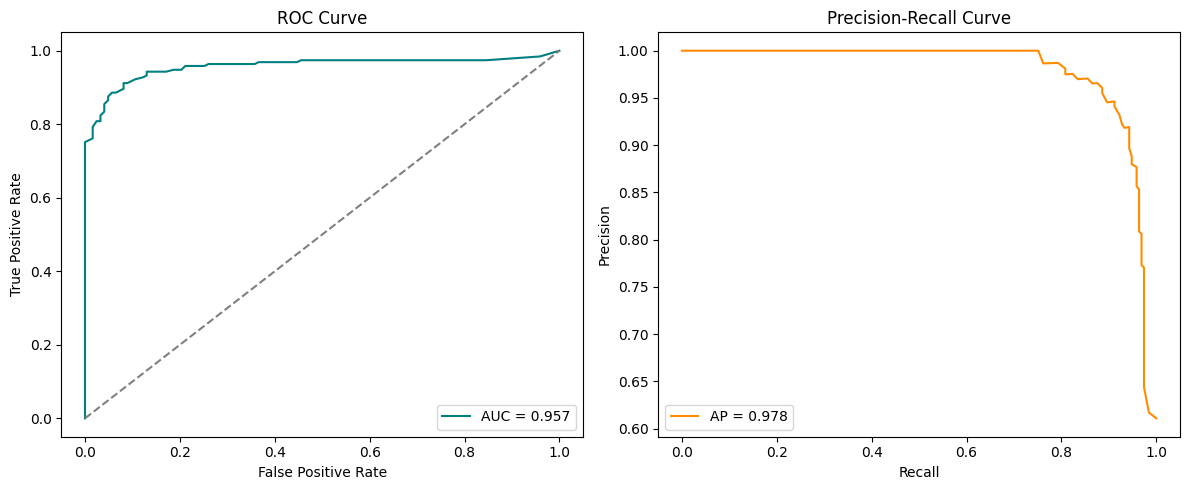

In [14]:
# ROC and Precision-Recall curves
fpr, tpr, _ = roc_curve(y_test_bin, y_score)
precision, recall, _ = precision_recall_curve(y_test_bin, y_score)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color="teal")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

# Precision-Recall curve
axes[1].plot(recall, precision, label=f"AP = {pr_auc:.3f}", color="darkorange")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

|--- day_sys_load_pct <= 37.10
|   |--- circadian_sys_night_des_pct <= 4.05
|   |   |--- all_avg_sys <= 121.25
|   |   |   |--- all_avg_dia <= 66.55
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- all_avg_dia >  66.55
|   |   |   |   |--- class: 0.0
|   |   |--- all_avg_sys >  121.25
|   |   |   |--- day_avg_sys <= 127.75
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- day_avg_sys >  127.75
|   |   |   |   |--- truncated branch of depth 5
|   |--- circadian_sys_night_des_pct >  4.05
|   |   |--- night_avg_sys <= 120.65
|   |   |   |--- night_avg_sys <= 118.35
|   |   |   |   |--- truncated branch of depth 10
|   |   |   |--- night_avg_sys >  118.35
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- night_avg_sys >  120.65
|   |   |   |--- night_avg_dia <= 71.10
|   |   |   |   |--- class: 1.0
|   |   |   |--- night_avg_dia >  71.10
|   |   |   |   |--- truncated branch of depth 2
|--- day_sys_load_pct >  37.10
|   |--- all_avg_dia <= 78.45

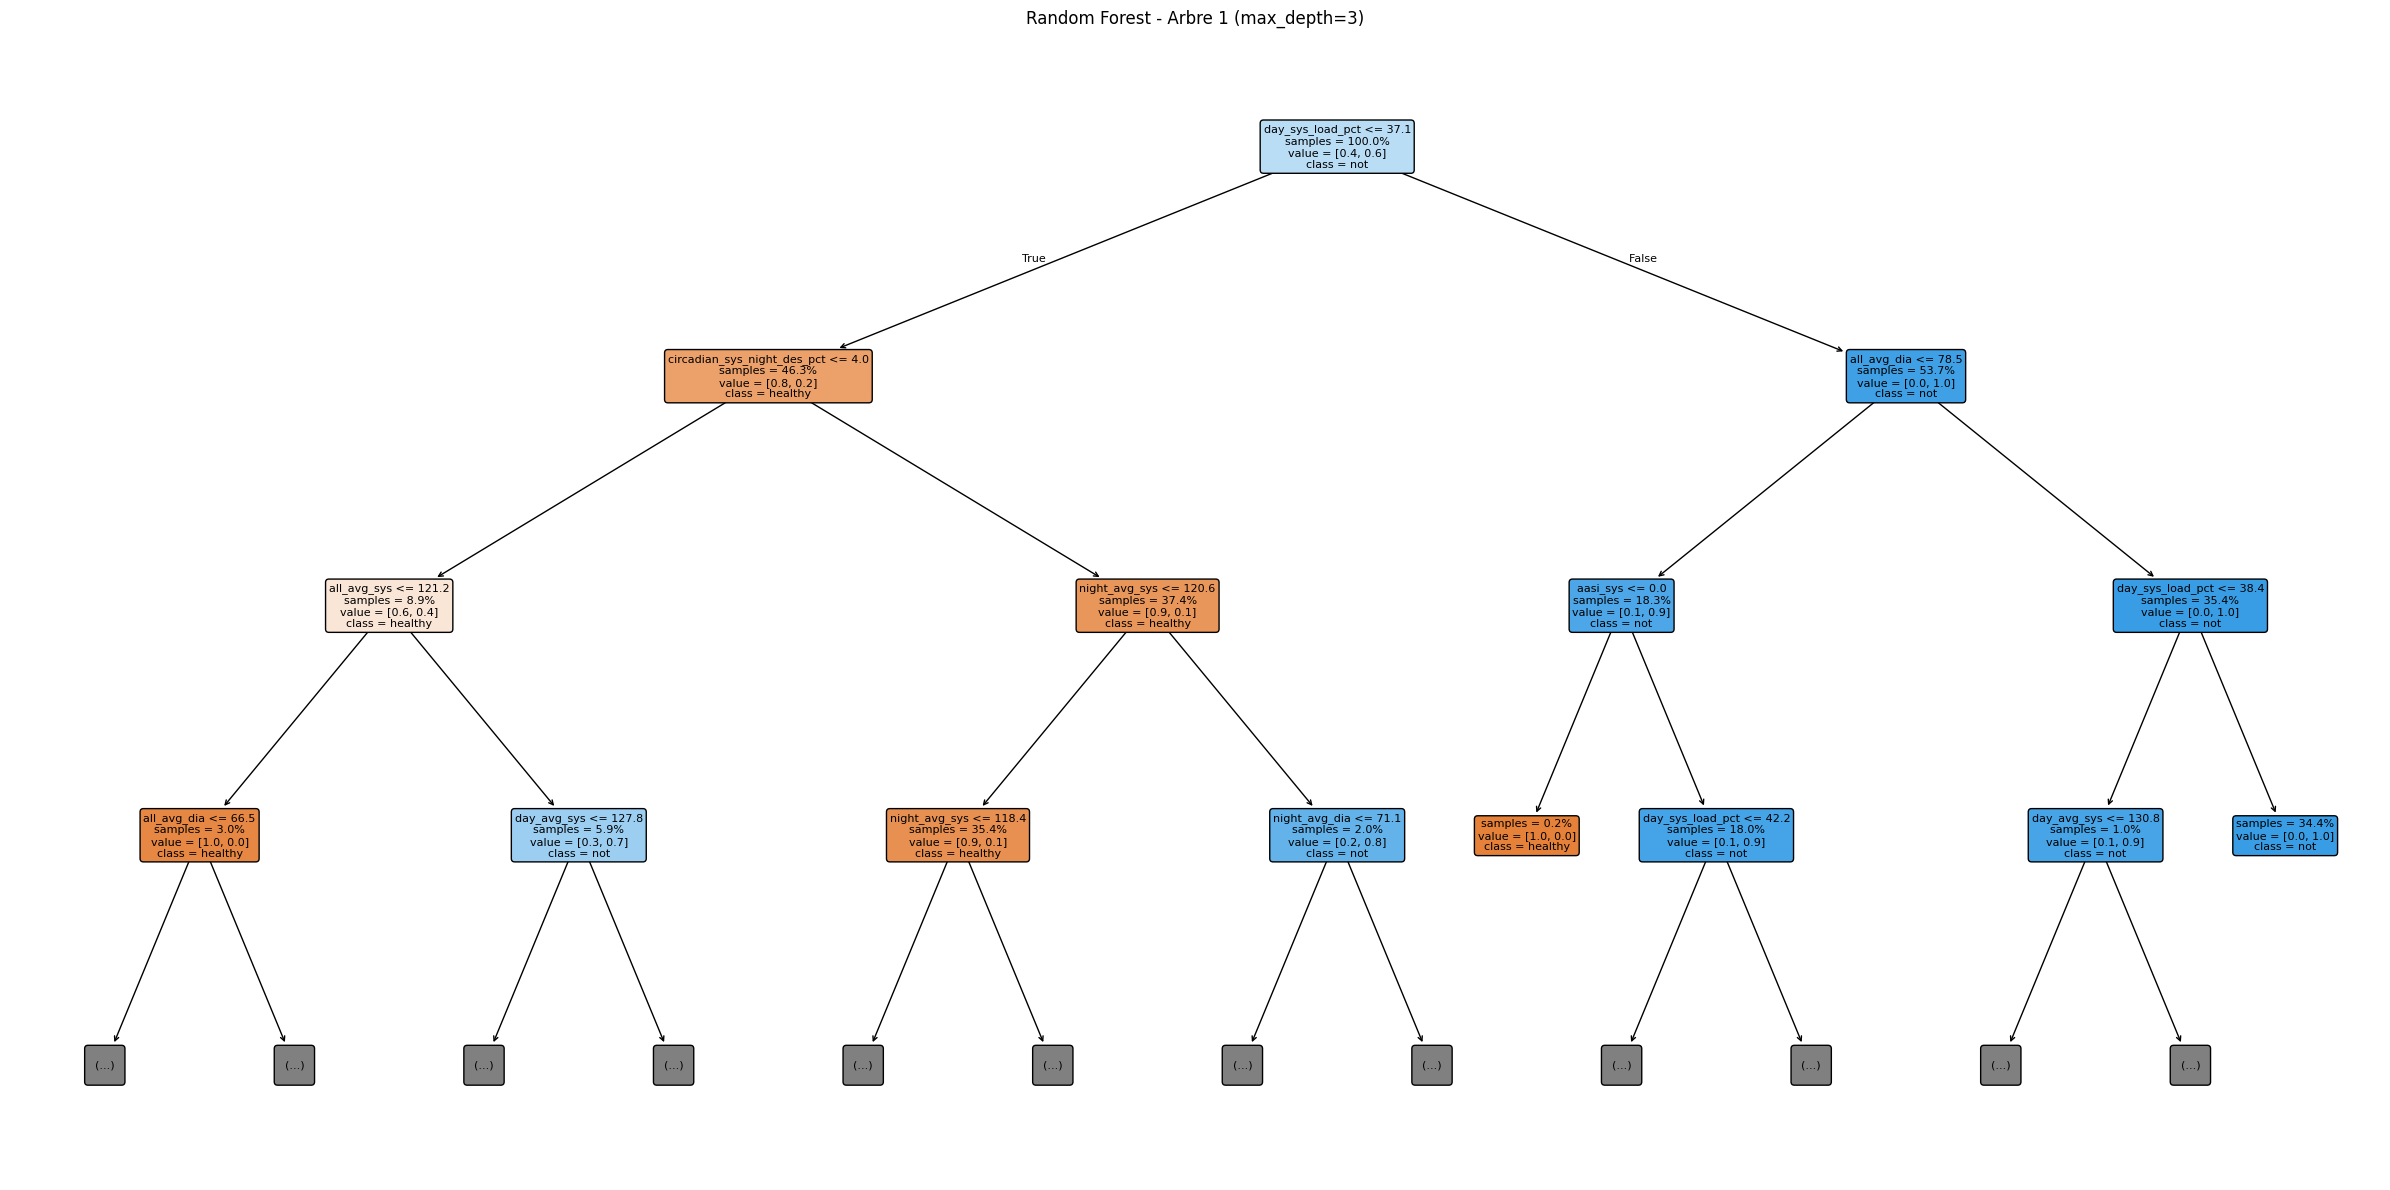

In [15]:
# Afficher les regles de l'arbre 1 (profondeur limitee pour lisibilite)
first_tree = model.estimators_[0]
tree_rules = export_text(first_tree, feature_names=list(X.columns), max_depth=3)
print(tree_rules)

# Visualiser l'arbre 1
plt.figure(figsize=(24, 12))
plot_tree(
    first_tree,
    feature_names=list(X.columns),
    class_names=list(le.classes_),
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    proportion=True,
    impurity=False,
    precision=1,
    node_ids=False,
 )
plt.title("Random Forest - Arbre 1 (max_depth=3)")
plt.tight_layout()
plt.show()

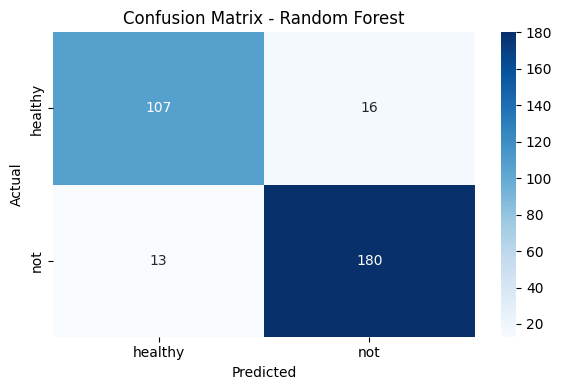

In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

Top 10 features:
                       feature  importance
0                  all_avg_sys    0.268836
1             day_sys_load_pct    0.184316
2                  day_avg_sys    0.162869
3                night_avg_sys    0.085170
4           night_sys_load_pct    0.069552
5                  all_avg_dia    0.042527
6                night_avg_dia    0.036066
7                  day_avg_dia    0.033551
8  circadian_sys_night_des_pct    0.027626
9             day_dia_load_pct    0.023935


C:\Users\USER\AppData\Local\Temp\ipykernel_11604\2254813744.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")


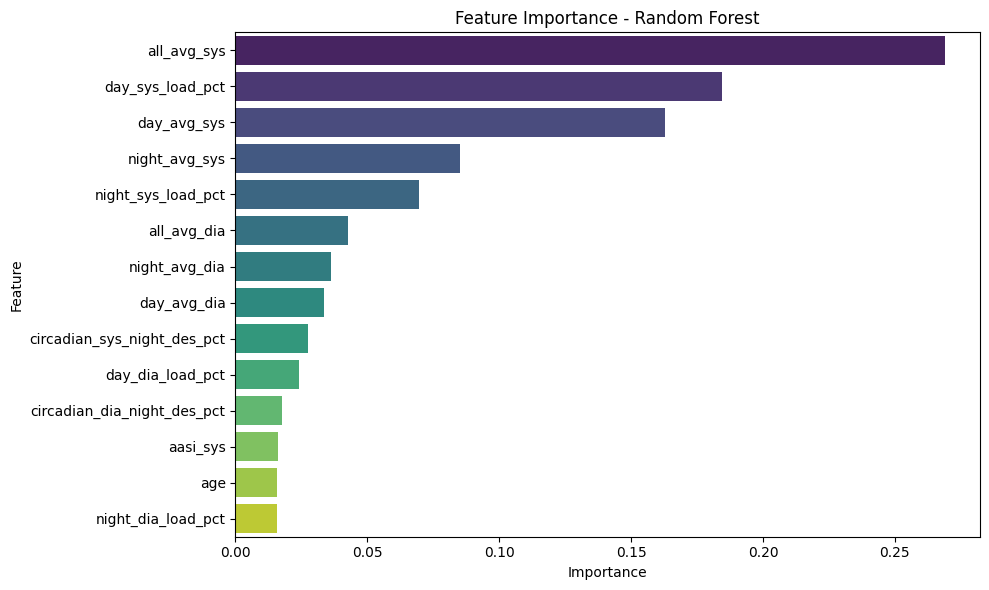

In [17]:
# Importance des variables
importance_df = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 features:")
print(importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [18]:
models_dir = Path("../models") if Path("../models").exists() else Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(model, models_dir / "random_forest.pkl")
joblib.dump(le, models_dir / "label_encoder.pkl")
joblib.dump(features, models_dir / "feature_names.pkl")

print("Model and artifacts saved to:", models_dir.resolve())

Model and artifacts saved to: C:\Users\USER\Desktop\MLProject\models
